## Importing the required Libraries

In [172]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [173]:
df = pd.read_csv('../data/futuristic_city_traffic.csv')
df.head()

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,SolarisVille,Drone,Snowy,Stable,Sunday,20,29.4268,0,0,14.7134,0.5241
1,AquaCity,Flying Car,Solar Flare,Recession,Wednesday,2,118.8000,0,0,143.5682,0.3208
2,Neuroburg,Autonomous Vehicle,Solar Flare,Recession,Wednesday,16,100.3904,0,0,91.2640,0.0415
3,Ecoopolis,Drone,Clear,Booming,Thursday,8,76.8000,1,0,46.0753,0.1811
4,AquaCity,Autonomous Vehicle,Solar Flare,Stable,Saturday,16,45.2176,0,0,40.1934,0.4544


In [174]:
df.columns

Index(['City', 'Vehicle Type', 'Weather', 'Economic Condition', 'Day Of Week',
       'Hour Of Day', 'Speed', 'Is Peak Hour', 'Random Event Occurred',
       'Energy Consumption', 'Traffic Density'],
      dtype='object')

In [175]:
df.shape

(1219567, 11)

## COLUMNS DESCRIPTION

City – The location of the observation. Useful for comparing patterns across different cities. Could be categorical.

Vehicle Type – Type of vehicle (e.g., car, bus, truck). Important for energy consumption and traffic analysis. Categorical variable.

Weather – Weather conditions during the observation (e.g., sunny, rainy, snowy). Impacts speed, energy consumption, and traffic density. Categorical.

Economic Condition – Possibly reflects city-level economic activity or status. Can affect traffic patterns. Categorical.

Day Of Week – Monday to Sunday. Helps identify weekday vs weekend trends. Categorical.

Hour Of Day – Numeric (0–23). Important for peak vs off-peak analysis.

Speed – Average speed of vehicles. Numeric. Could be influenced by traffic, weather, or time of day.

Is Peak Hour – Binary (Yes/No or 1/0). Useful for classifying traffic periods.

Random Event Occurred – Binary (Yes/No). Captures events like accidents or roadblocks that affect traffic and energy consumption.

Energy Consumption – Numeric. Could be fuel consumption or electricity for EVs. This could be your target variable in a regression model.

Traffic Density – Numeric or categorical (e.g., low, medium, high). Could be predicted from other features or used as another target variable.

In [176]:
df.shape  ## dataset shape

(1219567, 11)

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1219567 entries, 0 to 1219566
Data columns (total 11 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   City                   1219567 non-null  object 
 1   Vehicle Type           1219567 non-null  object 
 2   Weather                1219567 non-null  object 
 3   Economic Condition     1219567 non-null  object 
 4   Day Of Week            1219567 non-null  object 
 5   Hour Of Day            1219567 non-null  int64  
 6   Speed                  1219567 non-null  float64
 7   Is Peak Hour           1219567 non-null  int64  
 8   Random Event Occurred  1219567 non-null  int64  
 9   Energy Consumption     1219567 non-null  float64
 10  Traffic Density        1219567 non-null  float64
dtypes: float64(3), int64(3), object(5)
memory usage: 102.4+ MB


In [178]:
df.describe()

,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
count,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06,1.219567e+06
mean,1.150817e+01,5.994476e+01,1.546992e-01,4.988738e-02,4.946464e+01,2.770960e-01
std,6.919071e+00,2.663203e+01,3.616178e-01,2.177123e-01,2.528014e+01,2.191019e-01
min,0.000000e+00,6.693400e+00,0.000000e+00,0.000000e+00,4.929600e+00,5.900000e-03
25%,6.000000e+00,3.753310e+01,0.000000e+00,0.000000e+00,2.927395e+01,1.059000e-01
50%,1.200000e+01,5.847110e+01,0.000000e+00,0.000000e+00,4.578260e+01,2.186000e-01
75%,1.700000e+01,8.053455e+01,0.000000e+00,0.000000e+00,6.590550e+01,3.960000e-01
max,2.300000e+01,1.630886e+02,1.000000e+00,1.000000e+00,1.899489e+02,3.377600e+00


## Data Cleaning

In [179]:
df.isnull().sum()

City                     0
Vehicle Type             0
Weather                  0
Economic Condition       0
Day Of Week              0
Hour Of Day              0
Speed                    0
Is Peak Hour             0
Random Event Occurred    0
Energy Consumption       0
Traffic Density          0
dtype: int64

In [180]:
df.duplicated().sum()

np.int64(0)

## Removing Outliers

<Axes: >

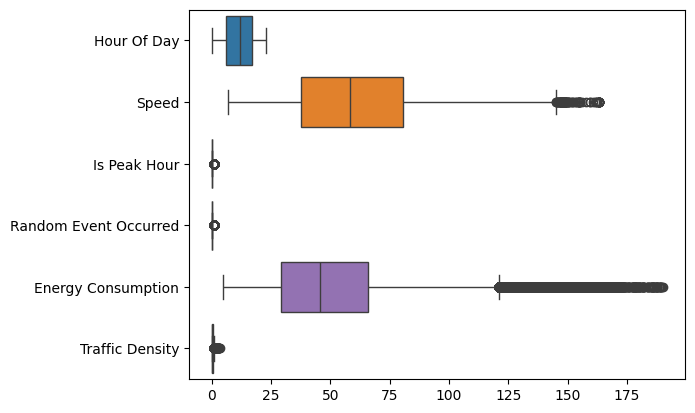

In [181]:
sns.boxplot(df,orient='h')

In [182]:
num_cols = df.select_dtypes(exclude='object')

In [183]:
## outliers remove function

def remove_outliers(df,col):
    q1 = df[col].quantile(0.05)
    q3 = df[col].quantile(0.60)
    iqr = q3-q1
    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr
    
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

for col in num_cols:
    df = remove_outliers(df,col)

<Axes: >

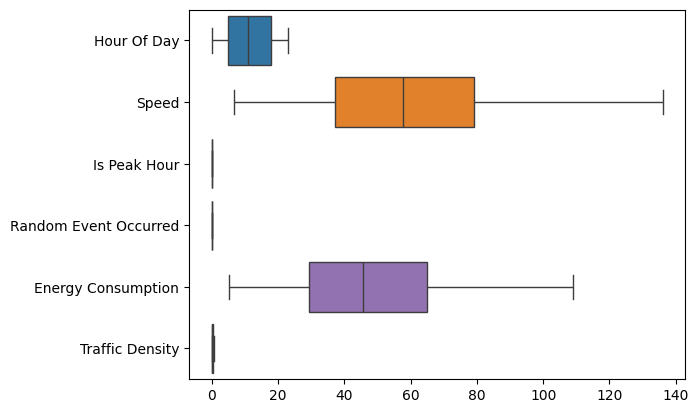

In [184]:
sns.boxplot(df,orient='h')

In [185]:
df = df.sample(frac=0.5, random_state=42)


In [186]:
df.shape

(444889, 11)

## Univariate Analysis

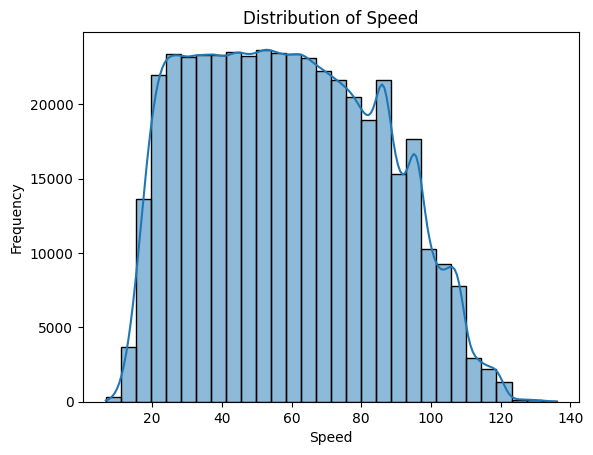

In [187]:
sns.histplot(df['Speed'], kde=True, bins=30)
plt.title(f"Distribution of Speed")
plt.xlabel("Speed")
plt.ylabel("Frequency")
plt.show()


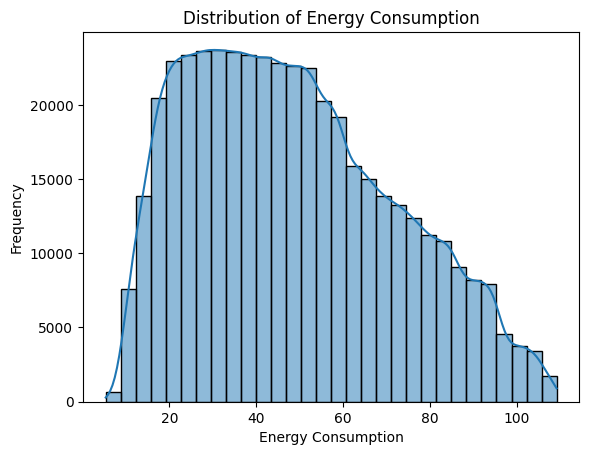

In [188]:
sns.histplot(df['Energy Consumption'],kde=True,bins=30)
plt.title("Distribution of Energy Consumption")
plt.xlabel('Energy Consumption')
plt.ylabel('Frequency')
plt.show()

In [189]:
df['Hour Of Day'].value_counts()

Hour Of Day
15    22234
16    22189
1     22128
11    22094
10    22050
20    22045
5     21996
23    21957
9     21937
21    21886
4     21849
0     21828
22    21826
19    21699
3     21678
6     21660
2     21515
13    15920
14    15812
12    15774
8      6347
17     6297
18     6128
7      6040
Name: count, dtype: int64

In [190]:
df.head()

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
269650,TechHaven,Autonomous Vehicle,Clear,Booming,Sunday,11,44.8573,0,0,40.7794,0.3386
353443,Ecoopolis,Car,Snowy,Recession,Thursday,14,41.4855,0,0,41.4855,0.0287
720557,SolarisVille,Autonomous Vehicle,Clear,Stable,Saturday,21,92.7553,0,0,74.2042,0.2881
448182,TechHaven,Autonomous Vehicle,Snowy,Booming,Sunday,1,99.3168,0,0,100.1938,0.2410
802973,SolarisVille,Autonomous Vehicle,Solar Flare,Recession,Tuesday,13,71.2191,0,0,56.9753,0.0852


In [191]:
df['Is Peak Hour'].value_counts()

Is Peak Hour
0    444889
Name: count, dtype: int64

In [192]:
df['Random Event Occurred'].value_counts()

Random Event Occurred
0    444889
Name: count, dtype: int64

<Axes: xlabel='Speed', ylabel='Energy Consumption'>

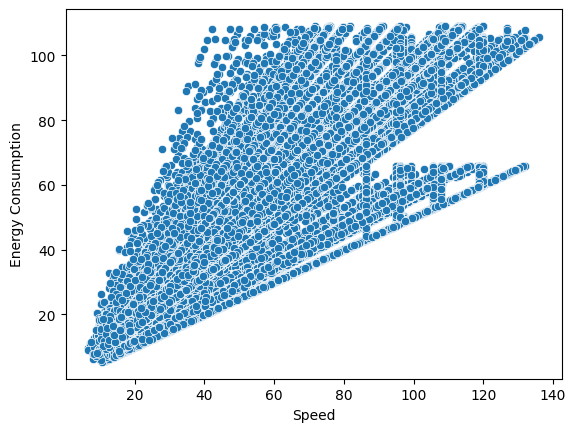

In [193]:
sns.scatterplot(x='Speed', y='Energy Consumption', data=df)

<Axes: >

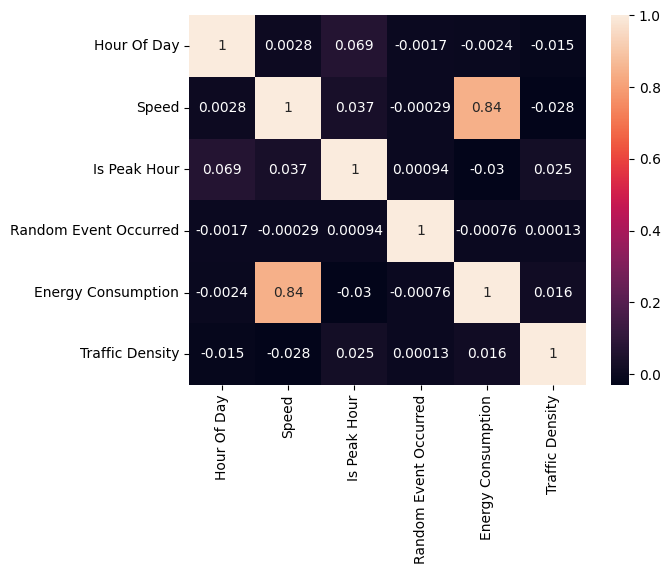

In [194]:
sns.heatmap(num_cols.corr(),annot=True)

In [195]:
df.columns

Index(['City', 'Vehicle Type', 'Weather', 'Economic Condition', 'Day Of Week',
       'Hour Of Day', 'Speed', 'Is Peak Hour', 'Random Event Occurred',
       'Energy Consumption', 'Traffic Density'],
      dtype='object')

In [196]:
y = df['Energy Consumption']
x = df.drop(columns=['Energy Consumption'])

## Splitting and Preprocessing

In [197]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20)

In [198]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 444889 entries, 269650 to 858308
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   City                   444889 non-null  object 
 1   Vehicle Type           444889 non-null  object 
 2   Weather                444889 non-null  object 
 3   Economic Condition     444889 non-null  object 
 4   Day Of Week            444889 non-null  object 
 5   Hour Of Day            444889 non-null  int64  
 6   Speed                  444889 non-null  float64
 7   Is Peak Hour           444889 non-null  int64  
 8   Random Event Occurred  444889 non-null  int64  
 9   Traffic Density        444889 non-null  float64
dtypes: float64(2), int64(3), object(5)
memory usage: 37.3+ MB


## Creating Pipeline

In [199]:
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline



categorical_cols = x_train.select_dtypes(include=['object', 'category']).columns

numeric_cols = x_train.select_dtypes(exclude=['object']).columns



preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OrdinalEncoder(), categorical_cols)
    ]
)

pipe = Pipeline([('Preprocessing',preprocessor), ('Model',KNeighborsRegressor())])


In [200]:
pipe.fit(x_train,y_train)

,steps,"[('Preprocessing', ...), ('Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [201]:
y_pred = pipe.predict(x_test)

In [202]:
from sklearn.metrics import r2_score

print(r2_score(y_test,y_pred))

0.9519261881355239


## Model PipeLine and Hyperparameter Tuning

In [203]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## Model tuning Parameters 

In [212]:

dt_params = {
    'Model__min_samples_split': [2, 3, 4,],
    'Model__max_depth': [1, 2, 3, 4,],
    'Model__min_samples_leaf': [2, 3, 4,]
}

lr_params = {
    'Model__alpha': [0.01, 0.1, 1, 10, 100],
    'Model__fit_intercept': [True, False]
}


rf_params = {
    'Model__n_estimators': [50,100],
    'Model__max_depth': [2,3,5, None],
    'Model__max_features': [2,3,4,5],
    'Model__min_samples_split': [2, 3,4,5,6]
}


xg_params = {
    'Model__learning_rate': [0.01, 0.1],
    'Model__n_estimators': [50,100],
    'Model__max_depth': [2, 3, 4, 5],
    'Model__colsample_bytree': [0.3, 0.4, 0.5, 0.8, 1.0]
}

knn_params = {
    'Model__n_neighbors' : range(3,12),
    'Model__metric': ['minkowski','euclidean','manhattan']
}



# Hyperparamter Tuning

### Linear Regression Tuning

In [205]:
from sklearn.model_selection import GridSearchCV

pipe1 = Pipeline(steps=[("Preprocessing",preprocessor),('Model',Ridge())])

grid = GridSearchCV(estimator=pipe1,param_grid=lr_params,cv=5,verbose=1,n_jobs=-1)

grid.fit(x_train,y_train)

y_pred_lr = grid.predict(x_test)

grid.best_params_


Fitting 5 folds for each of 10 candidates, totalling 50 fits


{'Model__alpha': 1, 'Model__fit_intercept': True}

# Decision Tree Tuning

In [206]:
from sklearn.model_selection import RandomizedSearchCV

pipe2 = Pipeline(steps=[('Preprocessing',preprocessor),('Model',DecisionTreeRegressor())])

rgrid = RandomizedSearchCV(estimator=pipe2,param_distributions=dt_params,cv=3,n_iter=5,verbose=1,n_jobs=-1)

rgrid.fit(x_train,y_train)

y_pred_dt = rgrid.predict(x_test)

rgrid.best_params_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


{'Model__min_samples_split': 4,
 'Model__min_samples_leaf': 4,
 'Model__max_depth': 4}

# Random Forest Tuning

In [207]:
pipe3 = Pipeline(steps=[('Preprocessing',preprocessor),('Model',RandomForestRegressor())])

rgrid = RandomizedSearchCV(estimator=pipe3,param_distributions=rf_params,cv=3,n_iter=3,verbose=1,n_jobs=-1)

rgrid.fit(x_train,y_train)

y_pred_rf = rgrid.predict(x_test)

rgrid.best_params_

Fitting 3 folds for each of 3 candidates, totalling 9 fits


{'Model__n_estimators': 50,
 'Model__min_samples_split': 3,
 'Model__max_features': 4,
 'Model__max_depth': 5}

# XgBoost Tuning

In [209]:
pipe4 = Pipeline(steps=[('Preprocessing',preprocessor),('Model',XGBRegressor())])

rgrid = RandomizedSearchCV(estimator=pipe4,param_distributions=xg_params,cv=3,n_iter=5,verbose=1,n_jobs=-1)

rgrid.fit(x_train,y_train)

y_pred_xg = rgrid.predict(x_test)

rgrid.best_params_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


{'Model__n_estimators': 100,
 'Model__max_depth': 5,
 'Model__learning_rate': 0.1,
 'Model__colsample_bytree': 0.5}

## KNearestRegressor Tuning

In [214]:
pipe5 = Pipeline(steps=[('Preprocessing',preprocessor),('Model',KNeighborsRegressor())])

rgrid = RandomizedSearchCV(estimator=pipe5,param_distributions=knn_params,cv=3,n_iter=5,verbose=1,n_jobs=-1)

rgrid.fit(x_train,y_train)

y_pred_kn = rgrid.predict(x_test)

rgrid.best_params_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


{'Model__n_neighbors': 4, 'Model__metric': 'euclidean'}

# Before Tuning Each Model Evaluation

In [215]:
models = [
    ('Linear Regression Ridge', Ridge()),
    ('KNN Regressor', KNeighborsRegressor()),
    ('Decision Tree', DecisionTreeRegressor()),
    ("Random Forest Regressor",RandomForestRegressor()),
    ('XgBoost',XGBRegressor())
]

def model_evaluation(models, preprocessor):
    for name, model in models:
        print(f'\n{name} Evaluation:')
        pipe = Pipeline([
            ('transformer', preprocessor),
            ('model', model)
        ])
        pipe.fit(x_train, y_train)
        y_pred = pipe.predict(x_test)
        print('R² Score:', r2_score(y_test, y_pred))


model_evaluation(models, preprocessor)
        
    


Linear Regression Ridge Evaluation:
R² Score: 0.7598758635339159

KNN Regressor Evaluation:
R² Score: 0.9519261881355239

Decision Tree Evaluation:
R² Score: 0.966126686124034

Random Forest Regressor Evaluation:
R² Score: 0.9821563431762592

XgBoost Evaluation:
R² Score: 0.983046153257199


# After Tuning

In [216]:
models = [
    ('Linear Regression Ridge', Ridge(alpha=1,fit_intercept=True)),
    ('KNN Regressor', KNeighborsRegressor(n_neighbors=4,metric='euclidean')),
    ('Decision Tree', DecisionTreeRegressor(min_samples_split=4,min_samples_leaf=4,max_depth=4)),
    ("Random Forest Regressor",RandomForestRegressor(n_estimators=50,min_samples_split=3,max_features=4,max_depth=5)),
    ('XgBoost',XGBRegressor(n_estimators=100,max_depth=5,learning_rate=0.1,colsample_bytree=0.5))
]

def model_evaluation(models, preprocessor):
    for name, model in models:
        print(f'\n{name} Evaluation:')
        pipe = Pipeline([
            ('transformer', preprocessor),
            ('model', model)
        ])
        pipe.fit(x_train, y_train)
        y_pred = pipe.predict(x_test)
        print('R² Score:', r2_score(y_test, y_pred))


model_evaluation(models, preprocessor)
        
    


Linear Regression Ridge Evaluation:
R² Score: 0.7598758635339159

KNN Regressor Evaluation:
R² Score: 0.9524769308080908

Decision Tree Evaluation:
R² Score: 0.9128712428271036

Random Forest Regressor Evaluation:
R² Score: 0.883354732597924

XgBoost Evaluation:
R² Score: 0.9782361056962525
